In [78]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [79]:
raw_data=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\Export_iButton.xlsx')
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9984 entries, 0 to 9983
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  9984 non-null   str  
 1   Message  9984 non-null   str  
 2   Status   9984 non-null   str  
dtypes: str(3)
memory usage: 234.1 KB


In [80]:
aux=pd.DataFrame()
aux=raw_data
aux['Headers']='NaN'

for i in range(0,aux.shape[0]):
    aux.iloc[i,3]=aux.iloc[i,2][0:8]

aux['Headers'].value_counts()

Headers
0x252513    7741
0x252501     788
0x252511     786
0x252514     504
0x252523     165
Name: count, dtype: int64

In [81]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9984 entries, 0 to 9983
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  9984 non-null   str  
 1   Message  9984 non-null   str  
 2   Status   9984 non-null   str  
 3   Headers  9984 non-null   str  
dtypes: str(4)
memory usage: 312.1 KB


Odometer

In [82]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux['Odometer in meters']=0.0
odometer=[]
date=[]
raw=[]
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    odometer.append(int(unit_aux.iloc[i,2][96:104],16))
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Odometer in meters']=odometer
unit_aux['Date']=date
unit_aux['Raw data']=raw

#print(unit_aux['Odometer in meters'])

unit=unit_aux.sort_values('Date',ascending=True)

print(unit.info())

<class 'pandas.DataFrame'>
Index: 8245 entries, 2 to 9983
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Created             8245 non-null   str  
 1   Message             8245 non-null   str  
 2   Status              8245 non-null   str  
 3   Headers             8245 non-null   str  
 4   Odometer in meters  8245 non-null   int64
 5   Date                8245 non-null   str  
 6   Raw data            8245 non-null   str  
dtypes: int64(1), str(6)
memory usage: 515.3 KB
None


260831164733 -> 0 -> 198.0 -> 0x252513005900180869487060172094003C38402D00000041460000000000640000000000000000FFFFFFFFFFFF00D5000000C6102608311647339A995A438A0A9AC22C9041C10000006703321252FFFFFF000021FFFFFFFFFF
260831165631 -> 1 -> 198.0 -> 0x252514005900220869487060172094003C38402D00000052510000000000640000000000000000FFFFFFFFFFFF03D5000000C6222608311656319A811245A82B8FC2511E83C10000000003681248FFFFFF0000260000FFFFFF
260831165817 -> 2 -> 198.0 -> 0x252514005900230869487060172094003C38402D0000004F520000000000640000000000000000FFFFFFFFFFFF03D5000000C6302608311658179A811245A82B8FC2511E83C10000000003701252FFFFFF0000270000FFFFFF
260831165821 -> 3 -> 198.0 -> 0x252514005900240869487060172094003C38402D0000004F520000000700644100000000000000FFFFFFFFFFFF16D5000000C6302608311658219A811245A82B8FC2511E83C10000000003701224FFFFFF0000270000FFFFFF
260831170017 -> 4 -> 198.0 -> 0x252513005900190869487060172094003C38402D00000059520000000700644100000000000000FFFFFFFFFFFF00D5000000C6342608311700179A811245

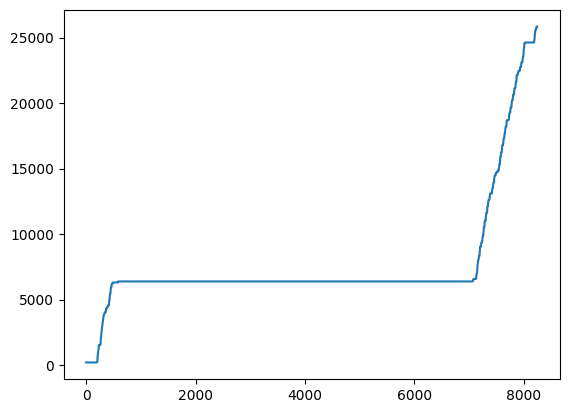

In [83]:
y_axis=[]
x_axis=[]
date=[]
raw_data_=[]

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,4]))
    x_axis.append(i)
    date.append(unit.iloc[i,5])
    raw_data_.append(unit.iloc[i,6])

#print("Delta odometer: ",y_axis[170]-y_axis[133],'meters')

for i in range(0,len(odometer)):
    print(date[i],'->',x_axis[i],'->',y_axis[i],'->',raw_data_[i])

#print(odometer[len(odometer)-1]-odometer[0])
plt.plot(x_axis,y_axis)

Speed

In [84]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
#unit_aux['Odometer in meters']=0.0
speed=[]
date=[]
raw=[]
unit_speed=pd.DataFrame()
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    try:
        lbs_ind=(bin(int(unit_aux.iloc[i,2][50:52],16) & 64))
        if lbs_ind=='0b1000000':
            speed.append(int(unit_aux.iloc[i,2][142:145]))  
            date.append(unit_aux.iloc[i,2][106:118])
            raw.append(unit_aux.iloc[i,2])
            print(lbs_ind)

    except:
        pass    

unit_speed['Speed']=speed
unit_speed['Date']=date
unit_speed['Raw data']=raw

unit=unit_speed.sort_values('Date',ascending=True)

print(unit.info())

0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000


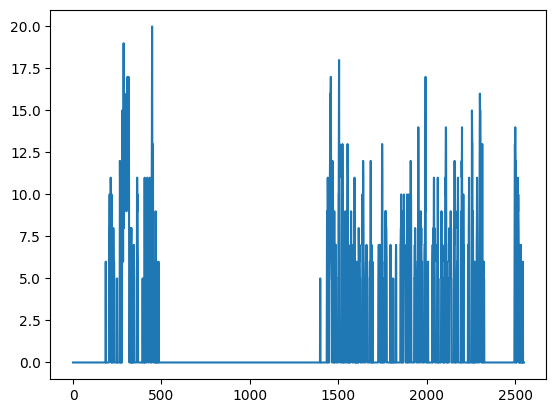

In [85]:
y_axis=[]
x_axis=[]
date=[]
raw_data_=[]

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,0]))
    x_axis.append(i)
    date.append(unit.iloc[i,1])
    raw_data_.append(unit.iloc[i,2])

plt.plot(x_axis,y_axis)

Historical events

In [86]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
satellite_number=[]
satellite_connection_indicator=[]
date=[]
raw=[]
num_events=0

for i in range(0,unit_aux.shape[0]):
    satellite_number.append(int(unit_aux.iloc[i,2][50:52],16) & 31)
    satellite_connection_indicator.append(int(unit_aux.iloc[i,2][50:52],16) & 0b10000000)
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

print(satellite_connection_indicator)
unit_aux['Satellites']=satellite_number
unit_aux['Satellite_connection_indicator']=satellite_connection_indicator
unit_aux['Raw data']=raw
unit_aux['date']=date

unit=unit_aux.sort_values('date',ascending=True)

unit.info()

for i in range(0,unit.shape[0]):
    if unit.iloc[i,5]>0:
        num_events=num_events+1
        print(unit.iloc[i,5],'->', unit.iloc[i,0], '->',unit.iloc[i,4],'->',unit.iloc[i,6])

print("Eventos históricos: ",num_events)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 0, 128, 128, 0, 128, 0, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 0, 128, 0, 0, 0, 128, 128, 0, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

Satellites Number

In [87]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
satellite_number=[]
satellite_connection_indicator=[]
date=[]
raw=[]
num_events=0

for i in range(0,unit_aux.shape[0]):
    satellite_number.append(int(unit_aux.iloc[i,2][50:52],16) & 31)
    satellite_connection_indicator.append(int(unit_aux.iloc[i,2][50:52],16) & 128)
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Satellites']=satellite_number
unit_aux['Satellite_connection_indicator']=satellite_connection_indicator
unit_aux['Raw data']=raw
unit_aux['date']=date

unit=unit_aux.sort_values('date',ascending=True)

unit.info()

for i in range(0,unit.shape[0]):
    if unit.iloc[i,4]<2:
        num_events=num_events+1
        print(unit.iloc[i,5],'->', unit.iloc[i,0], '->',unit.iloc[i,4],'->',unit.iloc[i,6])

print("Eventos históricos: ",num_events)

<class 'pandas.DataFrame'>
Index: 8245 entries, 2 to 9983
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   Created                         8245 non-null   str  
 1   Message                         8245 non-null   str  
 2   Status                          8245 non-null   str  
 3   Headers                         8245 non-null   str  
 4   Satellites                      8245 non-null   int64
 5   Satellite_connection_indicator  8245 non-null   int64
 6   Raw data                        8245 non-null   str  
 7   date                            8245 non-null   str  
dtypes: int64(2), str(6)
memory usage: 579.7 KB
0 -> 2026-09-04 00:34:01.445 -> 0 -> 0x252513005901570869487060172094003C38402D00000044000000000000644000000000000000FFFFFFFFFFFF00D5000018F10026090400342782CC000A02CD82CBC5A9010B013A00E603971254FFFFFF00001CFFFFFFFFFF
0 -> 2026-09-04 00:35:02.290 -> 0 -> 0x252513005901580

Coordinates

In [88]:
import struct

unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
latitude=[]
lat_aux=[]
longitude=[]
lon_aux=[]
speed=[]
date=[]
raw=[]
num_events=0

for i in range(0,unit_aux.shape[0]):
    latitude.append(unit_aux.iloc[i,2][134:142])
    longitude.append(unit_aux.iloc[i,2][126:134])
    lon_aux.append(struct.unpack('<f', bytes.fromhex(unit_aux.iloc[i,2][126:134]))[0])
    lat_aux.append(struct.unpack('<f', bytes.fromhex(unit_aux.iloc[i,2][134:142]))[0])    
    speed.append(int(unit_aux.iloc[i,2][142:145],16))
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Latitude']=latitude
unit_aux['Latitude_decoded']=lat_aux
unit_aux['Longitude']=longitude
unit_aux['Longitude_decoded']=lon_aux
unit_aux['Raw data']=raw
unit_aux['Date']=date
unit_aux['Speed']=speed

unit=unit_aux.sort_values('Date',ascending=True)

print(unit.info())

for i in range(0,unit.shape[0]):
    num_events=num_events+1
    print(unit.iloc[i,9],'->', unit.iloc[i,4], '->',unit.iloc[i,5],'->',unit.iloc[i,6],'->',unit.iloc[i,7],unit.iloc[i,8])

<class 'pandas.DataFrame'>
Index: 8245 entries, 2 to 9983
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Created            8245 non-null   str    
 1   Message            8245 non-null   str    
 2   Status             8245 non-null   str    
 3   Headers            8245 non-null   str    
 4   Latitude           8245 non-null   str    
 5   Latitude_decoded   8245 non-null   float64
 6   Longitude          8245 non-null   str    
 7   Longitude_decoded  8245 non-null   float64
 8   Raw data           8245 non-null   str    
 9   Date               8245 non-null   str    
 10  Speed              8245 non-null   int64  
dtypes: float64(2), int64(1), str(8)
memory usage: 773.0 KB
None
260831164733 -> 2C9041C1 -> -12.097698211669922 -> 8A0A9AC2 -> -77.02058410644531 0x252513005900180869487060172094003C38402D00000041460000000000640000000000000000FFFFFFFFFFFF00D5000000C6102608311647339A995A438A0A9AC22C90

In/Outs

15      14                 13      12      11      10      09      08       07 06 05 04 03 02 01 00
Power   Ignition/Input0    Input1  Input2  Input3  Input4  Input5  Input0

15=0, Connected
15=1. Disconnected

In [89]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux.info()
aux_cad=[]
aux_date=[]
aux_raw_data=[]
aux_input_number=[]
in_outs=[]

#unit_aux.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sym\concatenated.csv')

for i in range(0,unit_aux.shape[0]):
    long_cad=len(unit_aux.iloc[i,2])
    if ((long_cad>48) & (long_cad<204)):
        aux_cad.append(unit_aux.iloc[i,2])   

for i in range(0,len(aux_cad)):
    aux_value=aux_cad[i][64:68]
    aux_date.append(aux_cad[i][106:118])
    aux_raw_data.append(aux_cad[i])
    in_outs.append(bin (int (aux_cad[i][64:68],16) ))      

unit_=pd.DataFrame()
unit_['in and outs']=in_outs
unit_['date']=aux_date
unit_['raw data']=aux_raw_data

in_outs_df=unit_.sort_values('date',ascending=True)

in_outs_df.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sym\in_outs.csv')

<class 'pandas.DataFrame'>
Index: 8245 entries, 2 to 9983
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  8245 non-null   str  
 1   Message  8245 non-null   str  
 2   Status   8245 non-null   str  
 3   Headers  8245 non-null   str  
dtypes: str(4)
memory usage: 322.1 KB


Ignition

In [90]:
in_outs_df.info()

for i in range(0,in_outs_df.shape[0]):
    length=len(in_outs_df.iloc[i,0])
    if length>16:
        aux_ign=in_outs_df.iloc[i,0][2:3]
        if aux_ign=='1':
            print("Ignition On",in_outs_df.iloc[i,0])
        if aux_ign=='0':
            print("Ignition Off",in_outs_df.iloc[i,0])
    else:
        aux_ign=in_outs_df.iloc[i,0][2:3]
        if aux_ign=='1':
            print("Ignition On",in_outs_df.iloc[i,0])
        if aux_ign=='0':
            print("Ignition Off",in_outs_df.iloc[i,0])

<class 'pandas.DataFrame'>
Index: 8239 entries, 0 to 8238
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   in and outs  8239 non-null   str  
 1   date         8239 non-null   str  
 2   raw data     8239 non-null   str  
dtypes: str(3)
memory usage: 257.5 KB
Ignition Off 0b0
Ignition Off 0b0
Ignition Off 0b0
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition Off 0b0
Ignition Off 0b0
Ignition On 0b100000100000000
Ignition On 0b100

Door detection

In [91]:
x='0b0011000000000000' # for 16 bits, len=18

print(len(x),(x[4:6]))

y='0b011000000000000'   # for 15 bits, len=17
print(len(y), (y[3:5]))


18 11
17 11


In [92]:
in_outs=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sinthya\in_outs.csv',sep=',')
in_outs.info()
for i in range(0,in_outs.shape[0]):
    aux=(in_outs.iloc[i,1])
    if len(aux)==18:
        aux_2=(in_outs.iloc[i,1][4:6])
        if aux_2=='11':
            print(in_outs.iloc[i,1],len(aux),aux_2)
    if len(aux)==17:
        aux_2=(in_outs.iloc[i,1][3:5])
        if aux_2=='11':
            print(in_outs.iloc[i,1],len(aux),aux_2)

<class 'pandas.DataFrame'>
RangeIndex: 3378 entries, 0 to 3377
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Unnamed: 0   3378 non-null   int64
 1   in and outs  3378 non-null   str  
 2   date         3378 non-null   int64
 3   raw data     3378 non-null   str  
dtypes: int64(2), str(2)
memory usage: 105.7 KB


Panic detection

In [93]:
unit_.info()

<class 'pandas.DataFrame'>
RangeIndex: 8239 entries, 0 to 8238
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   in and outs  8239 non-null   str  
 1   date         8239 non-null   str  
 2   raw data     8239 non-null   str  
dtypes: str(3)
memory usage: 193.2 KB


In [94]:
for i in range(0,unit_.shape[0]):
    if unit_.iloc[i,2][92:94]=='42':
        print(unit_.iloc[i,2],unit_.iloc[i,1])

iButton

In [95]:
id_button_m=raw_data[raw_data['Headers'].str.contains('0x252523')]
device_id=[]
id_button_date=[]

id_button_m.info()

for i in range(0,id_button_m.shape[0]):
    device_id.append(id_button_m.iloc[i,2][84:100])
    id_button_date.append(id_button_m.iloc[i,2][32:44])
    print(id_button_m.iloc[i,2][84:100],id_button_m.iloc[i,2][32:44])

<class 'pandas.DataFrame'>
Index: 165 entries, 52 to 731
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  165 non-null    str  
 1   Message  165 non-null    str  
 2   Status   165 non-null    str  
 3   Headers  165 non-null    str  
dtypes: str(4)
memory usage: 6.4 KB
0900001802286301 260831173503
0900001802286301 260831173503
0900001802286301 260831173504
0900001802286301 260831173504
0900001802286301 260831173505
0900001802286301 260831173505
0900001802286301 260831173506
0900001802286301 260831173506
0900001802286301 260831173507
0900001802286301 260831173507
0900001802286301 260831173508
0900001802286301 260831173528
0900001802286301 260831173529
0900001802286301 260831173529
0900001802286301 260831173530
0900001802286301 260831173530
0900001802286301 260831173531
0900001802286301 260831173531
0900001802286301 260831173532
0900001802286301 260831173532
0900001802286301 260831173533
0900001802286301 260831173533